In [45]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import numpy as np

df = pd.read_csv("./data_cleaned/mines.csv")
df.drop(columns=["MagSus_SI"], inplace=True)

targets = [
    'Cobalt',
    'Copper',
    'Diamond',
    'Gold',
    'Graphite',
    'Lithium',
    'Nickel',
    'Rare Earth Elements (REE)',
    'Silver',
    'Uranium'
]

top_targets = [
    'Copper',
    'Diamond',
    'Gold',
    'Silver'
]

features = ['longitude', 'latitude', 'Vp_100_kms', 'Density_gcc',
       'elevation', 'SiO2_pct', 'Al2O3_pct', 'Fe2O3_pct', 'MgO_pct', 'CaO_pct',
       'Na2O_pct', 'K2O_pct', 'TiO2_pct', 'P2O5_pct', 'MnO_pct', 'Au_ppb',
       'Cu_ppm', 'Ni_ppm', 'Co_ppm', 'Li_ppm', 'Cr_ppm', 'Zn_ppm', 'Pb_ppm',
       'Mo_ppm', 'As_ppm', 'Th_ppm', 'U_ppm', 'La_ppm', 'Ce_ppm', 'Nd_ppm',
       'Nb_ppm', 'V_ppm', 'W_ppm'
]

In [46]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, hamming_loss
np.random.seed(42)
X = df[features]
y = df[top_targets].values

X_train, y_train, X_test, y_test = iterative_train_test_split(X.values, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
hamming_acc = 1 - hamming_loss(y_test, y_pred)
print("Hamming Accuracy:", hamming_acc)

for i, t in enumerate(top_targets):
    print(f"\n{t}")
    print(f"F1: {f1[i]:.3f}")
    print(f"Recall: {recall[i]:.3f}")
    print(f"Precision: {precision[i]:.3f}")

              precision    recall  f1-score   support

           0       0.81      0.54      0.64        54
           1       0.50      1.00      0.67         2
           2       0.84      0.77      0.81        84
           3       0.79      0.62      0.69        55

   micro avg       0.81      0.67      0.73       195
   macro avg       0.74      0.73      0.70       195
weighted avg       0.81      0.67      0.73       195
 samples avg       0.42      0.41      0.40       195

Hamming Accuracy: 0.8642857142857143

Copper
F1: 0.644
Recall: 0.537
Precision: 0.806

Diamond
F1: 0.667
Recall: 1.000
Precision: 0.500

Gold
F1: 0.807
Recall: 0.774
Precision: 0.844

Silver
F1: 0.694
Recall: 0.618
Precision: 0.791


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

In [55]:
X = df[features]
y = df[targets].values

X_train, y_train, X_test, y_test = iterative_train_test_split(X.values, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
hamming_acc = 1 - hamming_loss(y_test, y_pred)
print("Hamming Accuracy:", hamming_acc)

y_proba = model.predict_proba(X_test)
auc_scores = []

for i in range(len(targets)):
    if len(np.unique(y_test[:, i])) < 2:
        auc_scores.append(0)
    else:
        auc = roc_auc_score(y_test[:, i], y_proba[i][:, 1])
        auc_scores.append(auc)

auc_scores = np.array(auc_scores)

print(auc_scores)

for i, t in enumerate(targets):
    print(f"\n{t}")
    print(f"F1: {f1[i]:.3f}")
    print(f"Recall: {recall[i]:.3f}")
    print(f"Precision: {precision[i]:.3f}")

              precision    recall  f1-score   support

           0       0.20      0.08      0.12        12
           1       0.78      0.46      0.58        54
           2       0.67      1.00      0.80         2
           3       0.85      0.81      0.83        84
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       1.00      0.18      0.31        11
           7       0.00      0.00      0.00         0
           8       0.83      0.69      0.75        55
           9       1.00      1.00      1.00         4

   micro avg       0.81      0.62      0.71       224
   macro avg       0.53      0.42      0.44       224
weighted avg       0.79      0.62      0.68       224
 samples avg       0.46      0.44      0.43       224

Hamming Accuracy: 0.9337142857142857
[0.69222904 0.90480563 1.         0.90384615 0.5        0.09770115
 0.87444568 0.         0.91484848 1.        ]

Cobalt
F1: 0.118
Recall: 0.083
Preci

c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

C:\Users\jylis\AppData\Local\Temp\ipykernel_1184\767765040.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


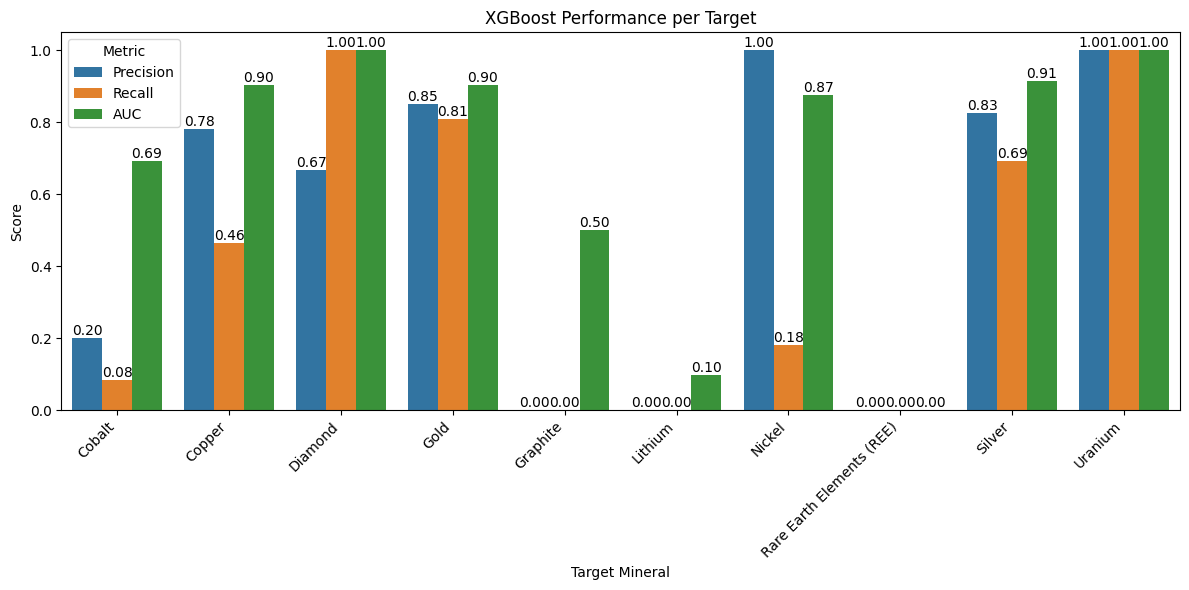

In [56]:
from matplotlib import pyplot as plt


metrics_df = pd.DataFrame({
    "Target Mineral": targets,
    # "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "AUC": auc_scores
})

metrics_long = metrics_df.melt(
    id_vars="Target Mineral",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=metrics_long,
    x="Target Mineral",
    y="Score",
    hue="Metric"
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("XGBoost Performance per Target")
plt.tight_layout()
plt.show()

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, recall_score, precision_score

X = df[features]
y = df[targets].values

X_train, y_train, X_test, y_test = iterative_train_test_split(X.values, y, test_size=0.2)


param_grid = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.1, 0.2],
    "estimator__subsample": [0.7, 0.8, 1.0],
    "estimator__colsample_bytree": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="recall_macro",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)
print(search.best_score_)

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)

y_proba = best_model.predict_proba(X_test)
auc_scores = []

for i in range(len(targets)):
    if len(np.unique(y_test[:, i])) < 2:
        auc_scores.append(0)
    else:
        auc = roc_auc_score(y_test[:, i], y_proba[i][:, 1])
        auc_scores.append(auc)

auc_scores = np.array(auc_scores)

print(auc_scores)

for i, t in enumerate(targets):
    print(f"\n{t}")
    print(f"Precision: {precision[i]:.3f}")
    print(f"Recall:    {recall[i]:.3f}")
    print(f"F1 Score:  {f1[i]:.3f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\multioutput.py", line 547, in fit
    super().fit(X, Y, sample_weight=sample_weight, **fit_params)
  File "c:\Users\jylis\AppData\Local\Programs\Python\Python310\

{'estimator__subsample': 0.7, 'estimator__n_estimators': 300, 'estimator__max_depth': 7, 'estimator__learning_rate': 0.01, 'estimator__colsample_bytree': 0.7}
nan
[0.75151515 0.91100398 1.         0.92445055 0.5        0.02298851
 0.79656319 0.         0.93242424 1.        ]

Cobalt
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Copper
Precision: 0.774
Recall:    0.444
F1 Score:  0.565

Diamond
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Gold
Precision: 0.873
Recall:    0.821
F1 Score:  0.847

Graphite
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Lithium
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Nickel
Precision: 1.000
Recall:    0.182
F1 Score:  0.308

Rare Earth Elements (REE)
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Silver
Precision: 0.833
Recall:    0.636
F1 Score:  0.722

Uranium
Precision: 1.000
Recall:    0.500
F1 Score:  0.667


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

C:\Users\jylis\AppData\Local\Temp\ipykernel_1184\1450357534.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


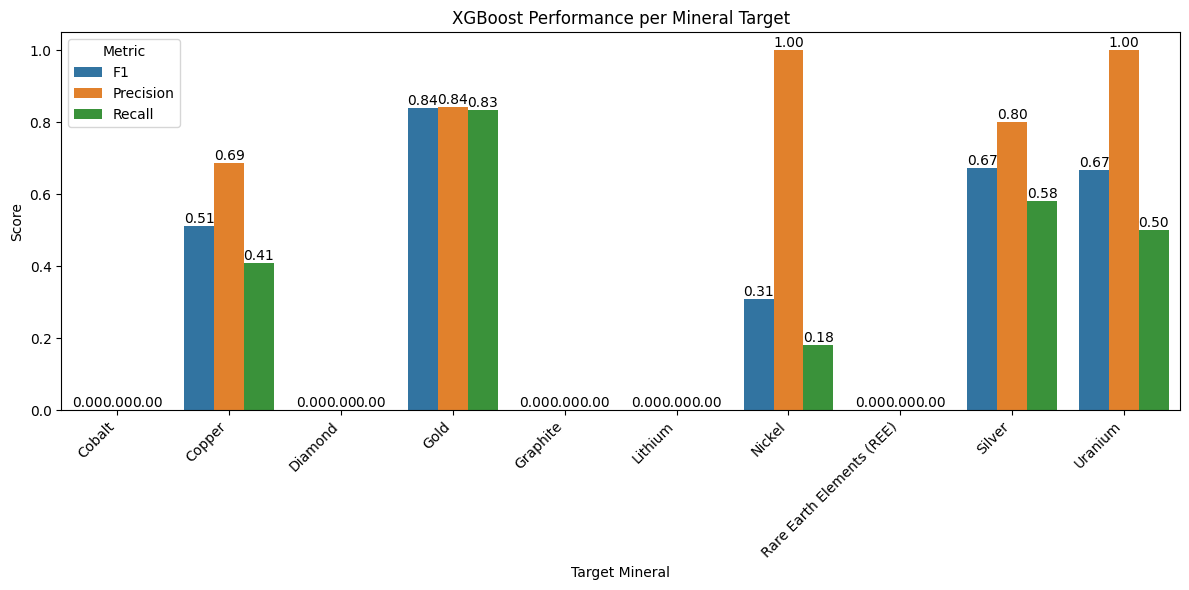

In [50]:
from matplotlib import pyplot as plt


metrics_df = pd.DataFrame({
    "Target Mineral": targets,
    "F1": f1,
    "Precision": precision,
    "Recall": recall
})

metrics_long = metrics_df.melt(
    id_vars="Target Mineral",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=metrics_long,
    x="Target Mineral",
    y="Score",
    hue="Metric"
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("XGBoost Performance per Mineral Target")
plt.tight_layout()
plt.show()

c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


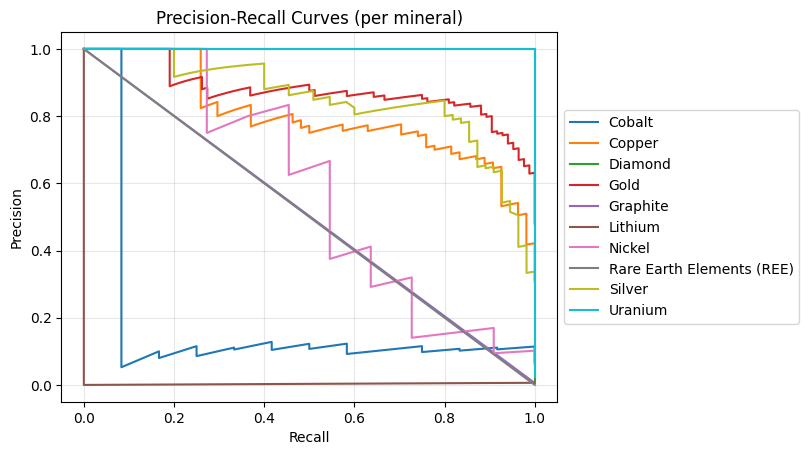

In [57]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i, name in enumerate(targets):
    proba = y_proba[i][:, 1]

    precision, recall, _ = precision_recall_curve(y_test[:, i], proba)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (per mineral)")
plt.grid(alpha=0.3)
plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [52]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance_df)

        feature    importance
10     Na2O_pct  4.857143e-02
4     elevation  2.342857e-02
16       Cu_ppm  2.171429e-02
21       Zn_ppm  1.542857e-02
7     Fe2O3_pct  1.314286e-02
18       Co_ppm  1.314286e-02
1      latitude  1.257143e-02
32        W_ppm  8.000000e-03
25       Th_ppm  5.142857e-03
3   Density_gcc  5.142857e-03
28       Ce_ppm  2.285714e-03
2    Vp_100_kms  2.285714e-03
11      K2O_pct  1.714286e-03
27       La_ppm  1.142857e-03
12     TiO2_pct  5.714286e-04
19       Li_ppm  5.714286e-04
6     Al2O3_pct -2.220446e-17
24       As_ppm -4.440892e-17
22       Pb_ppm -5.714286e-04
0     longitude -5.714286e-04
17       Ni_ppm -5.714286e-04
26        U_ppm -1.142857e-03
14      MnO_pct -1.142857e-03
13     P2O5_pct -1.142857e-03
29       Nd_ppm -1.714286e-03
9       CaO_pct -1.714286e-03
5      SiO2_pct -1.714286e-03
8       MgO_pct -2.857143e-03
15       Au_ppb -4.000000e-03
20       Cr_ppm -4.000000e-03
31        V_ppm -5.142857e-03
23       Mo_ppm -6.857143e-03
30       N